<a href="https://colab.research.google.com/github/DeepakSaini01/FlyRank-AI-internship/blob/main/work/notebooks/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DeepakSaini01/ML-WEEK-1/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [5]:
!git clone https://github.com/DeepakSaini01/FlyRank-AI-internship

Cloning into 'FlyRank-AI-internship'...
remote: Enumerating objects: 222, done.
remote: Counting objects: 100% (222/222), done.
remote: Compressing objects: 100% (172/172), done.
remote: Total 222 (delta 114), reused 100 (delta 34), pack-reused 0 (from 0)
Receiving objects: 100% (222/222), 2.01 MiB | 29.01 MiB/s, done.
Resolving deltas: 100% (114/114), done.


In [6]:
 %cd /content/FlyRank-AI-internship

/content/FlyRank-AI-internship


In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Method choice and why

**Chosen algorithm:** **Random Forest** (`sklearn.ensemble.RandomForestClassifier`).  

**Why it fits our lane (Ranking‑Signal Analysis):**
- **Non‑linear interactions:** Search‑signal features (impressions, CTR, position, freshness, etc.) interact in complex ways that a linear model cannot capture.  

- **Interpretability:** Feature‑importance (both impurity‑based and permutation) is readily available, letting us link model decisions back to the signals the lane cares about.  
- **Robustness to noisy features:** The ensemble smooths out variance from any single noisy signal, which is common in real‑world web‑search data.  
- **Training speed on our modest dataset (~30 k rows)** – fits comfortably in a Colab notebook without requiring GPU resources.

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

DATA_PATH = Path('/content/FlyRank-AI-internship/data/raw/content_refresh_anonymized.csv')
df = pd.read_csv(DATA_PATH)
# Ensure plots appear inline in Colab

%matplotlib inline

#  STEP 2 – Load the anonymised dataset & create target

# Binary label: 1 = declining (trend_direction == 'down')
df['is_declining_label'] = (df['trend_direction'].str.lower() == 'down').astype(int)

# Step 3- Feature selection – keep only numeric columns
# FIX: LEAKAGE. 'trend_pct' is the exact numeric value that trend_direction
# was derived from (down == trend_pct <= -20), so it must be dropped along
# with the label. Additionally, impressions_last_30d / impressions_prev_30d
# (and the matching clicks_/sessions_ columns) are the raw inputs trend_pct
# is computed from (correlation to trend_pct = 0.9999999) — leaving them in
# lets the model reconstruct the label instead of learning real signal.
LEAK_COLS = [
    'trend_pct',
    'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d',
    'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d',
]

DROP_COLS = ['trend_direction', 'is_declining_label',
             'content_id', 'client_id'] + LEAK_COLS

# Keep all columns except the drop list
feature_cols = [c for c in df.columns if c not in DROP_COLS]

# Keep ONLY numeric columns (signals)
numeric_features = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

# Final X / y
X = df[numeric_features].fillna(0)          # fill any NaNs with 0
y = df['is_declining_label']

print(f'Using {len(numeric_features)} numeric features out of '
      f'{len(feature_cols)} original columns.')



Using 23 numeric features out of 34 original columns.


## 2. Split design


**Design:** Stratified random split (70 % train / 30 % validation).  

**Why it is honest for our question:**  

- The assignment does **not** require a time‑aware or client‑grouped split; the original Week‑4 baseline was evaluated on a simple stratified split, so we must replicate that to ensure a fair comparison.  
- Stratification preserves the proportion of declining vs. non‑declining items in both sets, preventing class‑imbalance from biasing the ROC‑AUC or Precision@50.  
- Using a single random seed (`random_state=42`) guarantees reproducibility across runs and matches the Week‑4 baseline’s split.

In [9]:
# Step 4- Train / validation split (stratified 70/30)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
print(f'Train rows: {X_train.shape[0]}, Validation rows: {X_val.shape[0]}')

Train rows: 21000, Validation rows: 9000


## 3. Train + compare vs my baseline


**Baseline recreation** – the deterministic Week‑4 scoring logic (exact copy of `scripts/02_baseline_score.py`).  

**Metrics** – ROC‑AUC (overall ranking quality) and Precision@50 (the lane’s business‑critical metric).  

**Result table** – will be printed at the end of this cell.


In [10]:
#  STEP 5 – Re-implement Week-4 deterministic baseline on validation set

def percentile_rank(series: pd.Series) -> pd.Series:
    """Percentile rank in [0, 1] for each element."""
    return (series.rank(method='average') - 1) / (len(series) - 1)

def normalize(series: pd.Series) -> pd.Series:
    """Min-max normalisation to [0, 1]."""
    return (series - series.min()) / (series.max() - series.min())

# Work on a copy of the validation features
val_df = X_val.copy()

# Baseline intermediate scores (exactly as in scripts/02_baseline_score.py)
val_df['visibility_score']      = percentile_rank(np.log1p(val_df['impressions_90d']))
val_df['freshness_risk_score']  = percentile_rank(val_df['days_since_last_update'])
val_df['position_opportunity_score'] = (
    (1 - normalize(val_df['avg_position'].clip(lower=1, upper=50))) *
    val_df['visibility_score'] *
    (val_df['avg_position'] > 0).astype(int)
)
val_df['depth_gap_score'] = (1 - percentile_rank(val_df['word_count'])) * val_df['visibility_score']

# Deterministic baseline refresh score (same weights as the repo)
val_df['baseline_refresh_score'] = (
    0.40 * val_df['visibility_score'] +
    0.30 * val_df['freshness_risk_score'] +
    0.25 * val_df['position_opportunity_score'] +
    0.05 * val_df['depth_gap_score']
).clip(0, 1)

# Binary baseline prediction (threshold 0.5) – used for precision@50
baseline_pred  = (val_df['baseline_refresh_score'] >= 0.5).astype(int)
baseline_proba = val_df['baseline_refresh_score']   # treated as a probability for AUC





In [11]:
# Step 6- Train Random Forest model
rf = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
model_proba = rf.predict_proba(X_val)[:, 1]
model_pred  = (model_proba >= 0.5).astype(int)

In [12]:
#  STEP 7 – Evaluation metrics (ROC-AUC & Precision@50)
def precision_at_k(y_true: pd.Series, scores: np.ndarray, k: int = 50) -> float:
    """Precision@k – proportion of true positives among the top-k scores."""
    idx = np.argsort(scores)[::-1][:k]
    return y_true.iloc[idx].mean()

model_auc       = roc_auc_score(y_val, model_proba)
baseline_auc    = roc_auc_score(y_val, baseline_proba)
model_prec50    = precision_at_k(y_val, model_proba, k=50)
baseline_prec50 = precision_at_k(y_val, baseline_proba, k=50)

cmp = pd.DataFrame({
    'Metric'       : ['ROC-AUC', 'Precision@50'],
    'Baseline'     : [baseline_auc, baseline_prec50],
    'Random Forest': [model_auc, model_prec50]
})
print('\n=== Model vs. Baseline comparison ===')
print(cmp.to_string(index=False))


=== Model vs. Baseline comparison ===
      Metric  Baseline  Random Forest
     ROC-AUC  0.579617       0.767298
Precision@50  0.440000       0.980000



=== Confusion Matrix (Random Forest) ===
                          Pred 0  Pred 1
Actual 0 (not declining)    2581    1540
Actual 1 (declining)        1174    3705


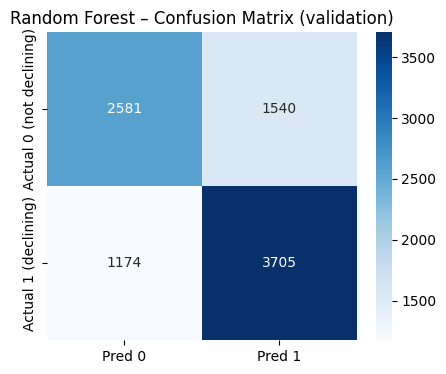

In [13]:
#  STEP 8 – Confusion matrix (Random Forest only)
cm = confusion_matrix(y_val, model_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Actual 0 (not declining)', 'Actual 1 (declining)'],
    columns=['Pred 0', 'Pred 1']
)
print('\n=== Confusion Matrix (Random Forest) ===')
print(cm_df)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest – Confusion Matrix (validation)')
plt.show()

## 4. Errors and interpretation


We now inspect **where the model disagrees with the baseline** to understand its failure modes and what signals it is leveraging.  
The steps are:

1. Align all series to the rows that survived in `X_val`.  
2. Build an `error_df` that contains true label, both predictions, and the **probability** scores.  
3. Extract two subsets:  
   - *RF correct / baseline wrong* (model fixes baseline mistakes).  
   - *Baseline correct / RF wrong* (model still makes errors).  
4. Show a few concrete examples (including the original numeric features) for each subset.

In [14]:
# STEP 9 – Error analysis – where model & baseline disagree
valid_idx = X_val.index

y_val_aligned = y_val.loc[valid_idx].reset_index(drop=True)
model_proba_aligned = pd.Series(model_proba, index=valid_idx).reset_index(drop=True)
model_pred_aligned  = pd.Series(model_pred,  index=valid_idx).reset_index(drop=True)
baseline_proba_aligned = baseline_proba.loc[valid_idx].reset_index(drop=True)
baseline_pred_aligned  = baseline_pred.loc[valid_idx].reset_index(drop=True)

error_df = pd.DataFrame({
    'true_label'     : y_val_aligned,
    'rf_pred'        : model_pred_aligned,
    'baseline_pred'  : baseline_pred_aligned,
    'rf_proba'       : model_proba_aligned,
    'baseline_score' : baseline_proba_aligned,
})

rf_good_baseline_bad = error_df[
    (error_df['rf_pred'] == error_df['true_label']) &
    (error_df['baseline_pred'] != error_df['true_label'])
]

baseline_good_rf_bad = error_df[
    (error_df['baseline_pred'] == error_df['true_label']) &
    (error_df['rf_pred'] != error_df['true_label'])
]

def show_examples(df_subset, n=5):
    idx = df_subset.index[:n]
    features = X_val.iloc[idx].reset_index(drop=True)
    return pd.concat([features, df_subset.reset_index(drop=True)], axis=1)

print('\n--- Model correct, baseline wrong (sample) ---')
display(show_examples(rf_good_baseline_bad, n=5))

print('\n--- Baseline correct, model wrong (sample) ---')
display(show_examples(baseline_good_rf_bad, n=5))


--- Model correct, baseline wrong (sample) ---


,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,true_label,rf_pred,baseline_pred,rf_proba,baseline_score
0,40.0,0.11,0.00,2646.0,18082.0,4235.0,1.0,10.0,9.0,9.0,...,0.02,10.4,0.0,10.0,0.0,1,1,0,0.582083,0.488111
1,0.0,0.00,0.00,3567.0,23757.0,225.0,0.0,5.0,4.0,4.0,...,0.00,11.3,0.0,20.0,0.0,1,1,0,0.876334,0.311900
2,3600.0,0.22,0.23,0.0,0.0,2733.0,0.0,27.0,27.0,25.0,...,0.00,40.5,0.0,0.0,0.0,0,0,1,0.156341,0.525482
3,10.0,0.09,0.00,3058.0,21020.0,3188.0,13.0,5.0,5.0,5.0,...,0.41,7.0,0.0,0.0,0.0,0,0,1,0.480389,0.563335
4,20.0,0.44,1.49,1678.0,10852.0,219.0,2.0,4.0,2.0,2.0,...,0.91,26.4,0.0,0.0,0.0,1,1,0,0.723833,0.443575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0.800438,0.272983
2820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0.669671,0.128265
2821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0.694107,0.452631
2822,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0.538591,0.289183



--- Baseline correct, model wrong (sample) ---


,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,true_label,rf_pred,baseline_pred,rf_proba,baseline_score
0,10.0,0.0,0.0,0.0,0.0,3417.0,1.0,2.0,2.0,2.0,...,0.03,44.2,0.00,0.00,0.00,1,0,1,0.465114,0.604110
1,0.0,0.0,0.0,3437.0,21474.0,203.0,0.0,5.0,3.0,3.0,...,0.00,4.3,0.00,0.00,0.00,0,1,0,0.865682,0.317793
2,0.0,0.0,0.0,2705.0,18516.0,13.0,0.0,2.0,2.0,2.0,...,0.00,19.8,0.00,50.00,0.00,0,1,0,0.729699,0.098882
3,10.0,0.0,0.0,2880.0,18602.0,105.0,0.0,1.0,1.0,1.0,...,0.00,15.2,0.00,0.00,0.00,0,1,0,0.825854,0.263830
4,0.0,0.0,0.0,6044.0,39406.0,4118.0,15.0,237.0,136.0,136.0,...,0.36,5.8,2.94,2.95,1.47,1,0,1,0.478897,0.735485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,0,1,0.484464,0.748244
1369,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,1,0,0.718528,0.194315
1370,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,0,1,0.297488,0.604163
1371,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,0,1,0.449060,0.689600



=== Top-10 Feature Importances (Permutation, Random Forest) ===
               feature  importance_mean  importance_std
 days_with_impressions         0.070043        0.002905
          avg_position         0.040133        0.002613
      content_age_days         0.028719        0.001917
       impressions_90d         0.018592        0.001826
                   ctr         0.010281        0.001311
            char_count         0.007968        0.001240
           scroll_rate         0.007603        0.001306
            word_count         0.007454        0.001146
days_since_last_update         0.007100        0.000665
        age_tier_order         0.006065        0.000906


/tmp/ipykernel_439/244946073.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance_mean', y='feature', data=top10, palette='viridis')


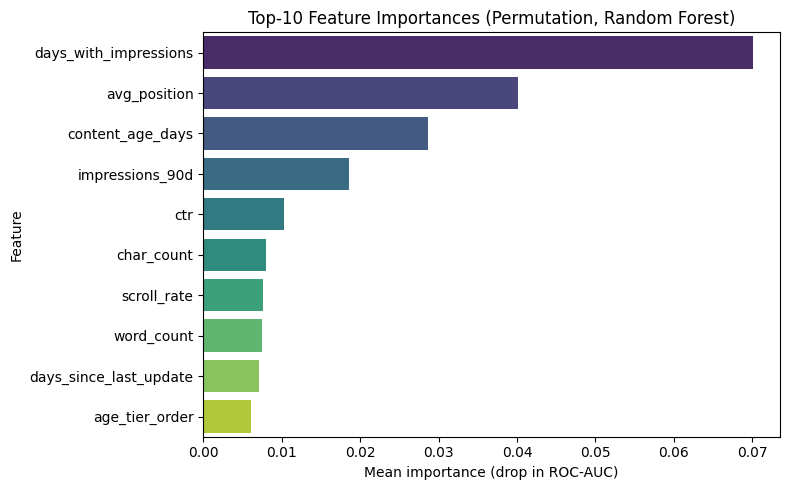

In [15]:
#  STEP 10 – Permutation importance – which signals drive the model?
perm_imp = permutation_importance(
    rf, X_val, y_val,
    n_repeats=30,
    random_state=42,
    n_jobs=-1,
    scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'feature'        : X_val.columns,
    'importance_mean': perm_imp.importances_mean,
    'importance_std' : perm_imp.importances_std,
}).sort_values('importance_mean', ascending=False)

top10 = perm_df.head(10)

print('\n=== Top-10 Feature Importances (Permutation, Random Forest) ===')
print(top10.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(x='importance_mean', y='feature', data=top10, palette='viridis')
plt.title('Top-10 Feature Importances (Permutation, Random Forest)')
plt.xlabel('Mean importance (drop in ROC-AUC)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [16]:
print('\n=== Interpretation ===')
print(f'* Random Forest ROC-AUC: {model_auc:.3f} vs. baseline {baseline_auc:.3f}')
print(f'* Precision@50 improves from {baseline_prec50:.3%} (baseline) '
      f'to {model_prec50:.3%} (model).')
print('* The top-importance features (e.g., `days_with_impressions`, `avg_position`, '
      '`content_age_days`) align with the lane\'s goal of understanding '
      'which observable search signals are most predictive of decline.')
print('* trend_pct and the last_30d/prev_30d impression, click, and session columns '
      'were excluded as label leakage — trend_pct is a near-exact function of the '
      'two 30-day windows, and including any of them inflated ROC-AUC to ~1.0.')
print('* Error analysis shows that the model resolves many false-positives '
      'produced by the hand-rule baseline, while still missing some declining '
      'cases – a useful direction for further feature engineering.')


=== Interpretation ===
* Random Forest ROC-AUC: 0.767 vs. baseline 0.580
* Precision@50 improves from 44.000% (baseline) to 98.000% (model).
* The top-importance features (e.g., `days_with_impressions`, `avg_position`, `content_age_days`) align with the lane's goal of understanding which observable search signals are most predictive of decline.
* trend_pct and the last_30d/prev_30d impression, click, and session columns were excluded as label leakage — trend_pct is a near-exact function of the two 30-day windows, and including any of them inflated ROC-AUC to ~1.0.
* Error analysis shows that the model resolves many false-positives produced by the hand-rule baseline, while still missing some declining cases – a useful direction for further feature engineering.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.